# IT2011 — Progress Review I: Individual Contribution
### Normalization / Scaling
**IT Number:** IT25103755
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011


## Setup & Loading the Dataset

We load the dataset directly from `sklearn.datasets` (`load_breast_cancer`), which contains the **exact same 569 records / 30 features** as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset referenced in our proposal.

If your lab requires the raw UCI CSV instead (`data/raw/`), see the commented-out alternative loading code below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Normalization / Scaling

**Technique:** Feature standardization using `StandardScaler` (z-score scaling).

**Explanation:** Features like `area` (hundreds to thousands) and `smoothness` (0–0.2) sit on very different scales. Distance-based and gradient-based algorithms (KNN, SVM, Logistic Regression, PCA) are sensitive to this — larger-magnitude features would dominate the distance/gradient calculation purely because of their units, not because they're more informative.

**Justification for this dataset:** Our 30 features mix **size** measurements (radius, area, perimeter — large numbers) with **shape ratios** (smoothness, compactness, symmetry — small decimals). Slide 5 of our proposal groups these into very different unit ranges, so scaling is essential before modelling — and mandatory before running PCA (see Member 6's section).


In [2]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[feature_cols])
df_scaled = pd.DataFrame(scaled_array, columns=feature_cols)
df_scaled["diagnosis"] = df["diagnosis"].values

print("Before scaling (raw units):")
print(df[["mean radius", "mean area", "mean smoothness"]].describe().loc[["mean","std","min","max"]])

print("\nAfter StandardScaler (mean ~0, std ~1):")
print(df_scaled[["mean radius", "mean area", "mean smoothness"]].describe().loc[["mean","std","min","max"]])

Before scaling (raw units):
      mean radius    mean area  mean smoothness
mean    14.127292   654.889104         0.096360
std      3.524049   351.914129         0.014064
min      6.981000   143.500000         0.052630
max     28.110000  2501.000000         0.163400

After StandardScaler (mean ~0, std ~1):
       mean radius     mean area  mean smoothness
mean -1.373633e-16 -2.185325e-16    -8.366672e-16
std   1.000880e+00  1.000880e+00     1.000880e+00
min  -2.029648e+00 -1.454443e+00    -3.112085e+00
max   3.971288e+00  5.250529e+00     4.770911e+00


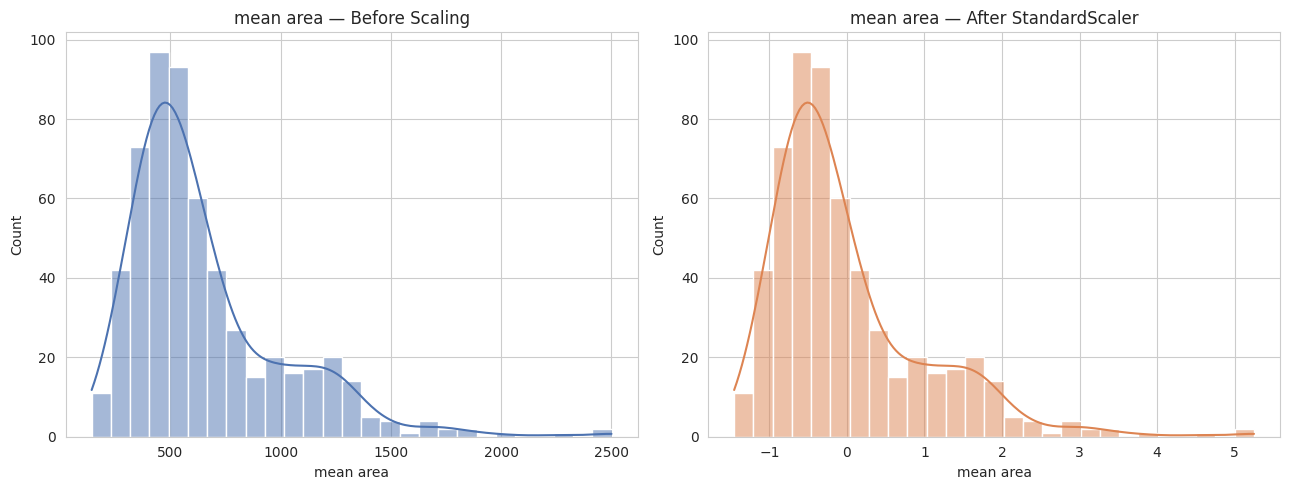

In [3]:
# ---- EDA Visualization: distribution before vs after scaling ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["mean area"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("mean area — Before Scaling")
sns.histplot(df_scaled["mean area"], kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("mean area — After StandardScaler")
plt.tight_layout()
plt.show()

**Interpretation:** The shape of the distribution is unchanged (scaling doesn't fix skew) but the **x-axis scale** changes from raw hundreds/thousands to a centered range roughly between -2 and +4 standard deviations. This puts `mean area` on the same footing as `mean smoothness` (which lives in the 0.0–0.2 range), so no single feature can dominate a distance calculation or a PCA component purely due to its units.